# NOVEL
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@ens.psl.eu or vineethfrancis.physics@gmail.com
- Nuclear Orientation via Electron Spin Locking
- In Hilbert Space
- Redfield Master equation
- Thanks to Pulsed DNP Workshop at Lyon 2026 (Sami Jannin and team)

In [1]:
# Define the source path
SourcePath = '/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)
import time
%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
from PyOR_Evolution import Evolutions
from PyOR_Plotting import Plotting
import PyOR_SignalProcessing as Spro

In [2]:
# Define the spin system
Spin_list = {"A" : "E", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)

# initialize the system
QS.Initialize()

### Set parameters

In [3]:
# Master Equation
QS.PropagationSpace = "Hilbert"
QS.MasterEquation = "Redfield"

# B0 Field in Tesla, Static Magnetic field (B0) along Z
QS.B0 = 0.3475

# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = 0.0
QS.OFFSET["B"] = 0.0

# Relaxation Process
QS.Rprocess = "No Relaxation"

QS.Update()


Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [61194749999.99999, -92963895.0] from {'A': 61194749999.99999, 'B': -92963895.0}
Offset    <- OFFSET    : [0.0, 0.0] from {'A': 0.0, 'B': 0.0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [9739.44695377  -14.79566342]


### Generate Hamiltonians

In [4]:
Omega_A = QS.OMEGA_RF["B"] # Proton Larmor Frequency
Omega1 = Omega_A           # NOVEL condition, Match Rabi frequnecy to Nuclear Larmor

# Nuclear Zeeman Hamiltonina
Hz = Omega_A * QS.Bz
Hz.matrix

Matrix([
[-46481947.5,          0,           0,          0],
[          0, 46481947.5,           0,          0],
[          0,          0, -46481947.5,          0],
[          0,          0,           0, 46481947.5]])

In [5]:
# Hyperfine coupling
A = 2.0 * 3.14 * 1.0e6
Hh = A * QS.Az * QS.Bx
Hh.matrix

Matrix([
[        0, 1570000.0,          0,          0],
[1570000.0,         0,          0,          0],
[        0,         0,          0, -1570000.0],
[        0,         0, -1570000.0,          0]])

In [6]:
# Microwave
Hm = Omega1 * QS.Ax
Hm.matrix 

Matrix([
[          0,           0, -46481947.5,           0],
[          0,           0,           0, -46481947.5],
[-46481947.5,           0,           0,           0],
[          0, -46481947.5,           0,           0]])

In [7]:
# Total Hamiltonina
H = Hz + Hh + Hm
H.matrix

Matrix([
[-46481947.5,   1570000.0, -46481947.5,           0],
[  1570000.0,  46481947.5,           0, -46481947.5],
[-46481947.5,           0, -46481947.5,  -1570000.0],
[          0, -46481947.5,  -1570000.0,  46481947.5]])

### Initialize Density Matrix

In [8]:
rho_in = QS.Az
rhoeq = QS.Az

### Pulse

In [9]:
HardP = HardPulse(QS)

flip_angle1 = 90.0   # Flip angle Spin 1

rho = HardP.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)

## Evolution 

In [10]:
Contact_time = 2e-6
QS.AcqDT =  Contact_time / 100.0
QS.AcqAQ = Contact_time

QS.PropagationMethod = "Unitary Propagator"

Ham = Hamiltonian(QS)
EVol = Evolutions(QS,Ham)

start_time = time.time()
t, rho_t = EVol.Evolution(rho,rhoeq,H)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Larmor Frequency in MHz:  [9739.44695377  -14.79566342]
Larmor Frequency in MHz:  [9739.44695377  -14.79566342]
Total time = 0.0018618106842041016 seconds 


### Expectation Value

In [11]:
det_X1 = QS.Ax
det_Z2 = QS.Bz

t, signal_X1 = EVol.Expectation(rho_t,det_X1)
t, signal_Z2 = EVol.Expectation(rho_t,det_Z2)

## Plotting

In [12]:
plot = Plotting(QS)

In [13]:
BS = Basis(QS)
Zstates, DicZ = BS.Zeeman_Basis()

/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc/PyOR_Plotting.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + xlabel, rotation='vertical')
/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc/PyOR_Plotting.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + ylabel)
/home/vineeth/.conda/envs/pyor/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


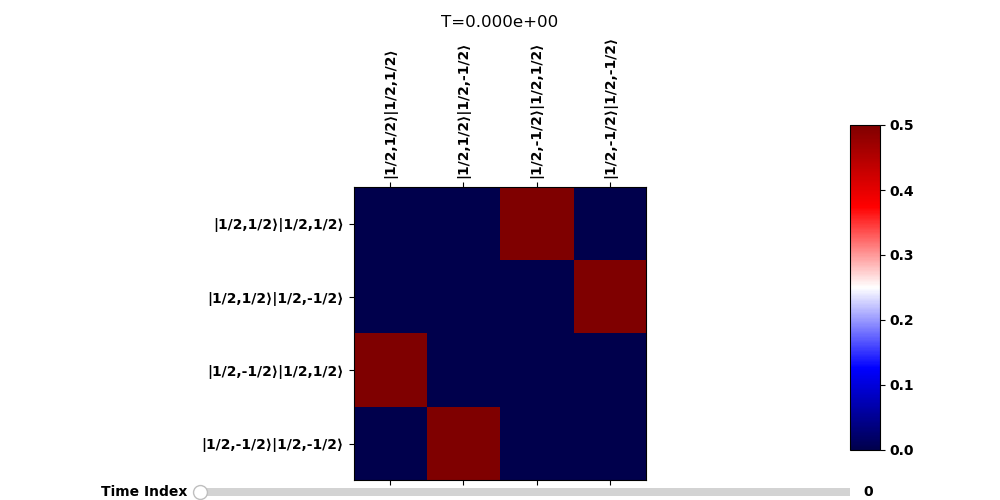

In [19]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 10
plot.MatrixPlot_slider(t, rho_t, DicZ, DicZ)

/home/vineeth/.conda/envs/pyor/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/vineeth/.conda/envs/pyor/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self.figure.savefig(buf, format='png', dpi='figure')


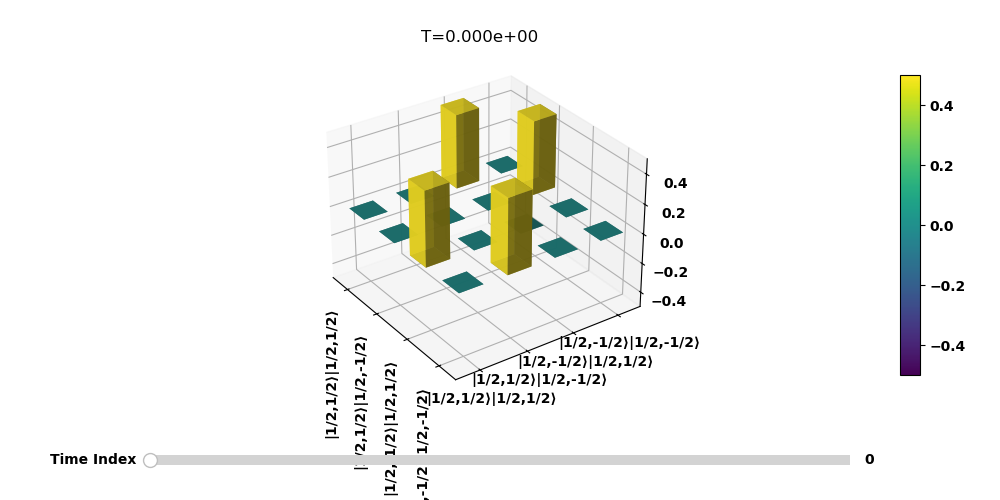

In [18]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 10
plot.MatrixPlot3D_slider(t, rho_t, DicZ, DicZ)

/home/vineeth/.conda/envs/pyor/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/.conda/envs/pyor/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


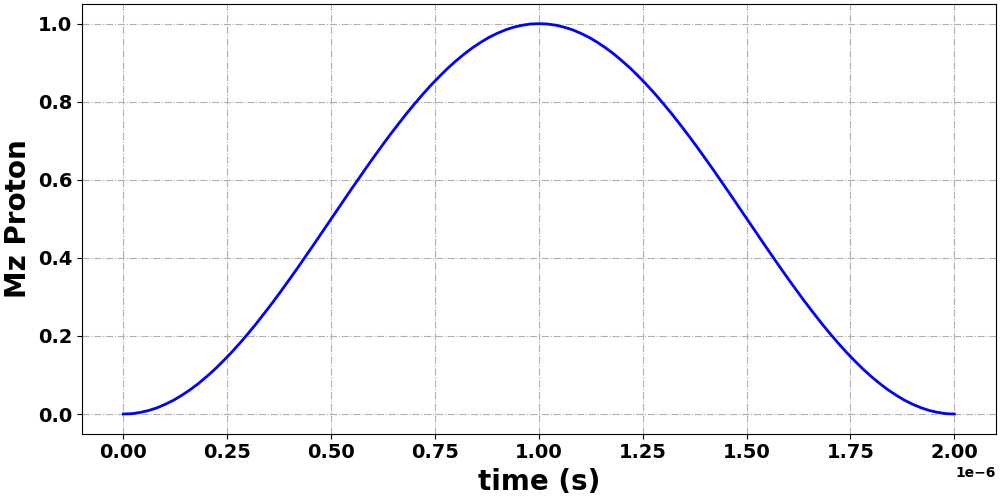

In [16]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting(t,signal_Z2,"time (s)","Mz Proton","blue")

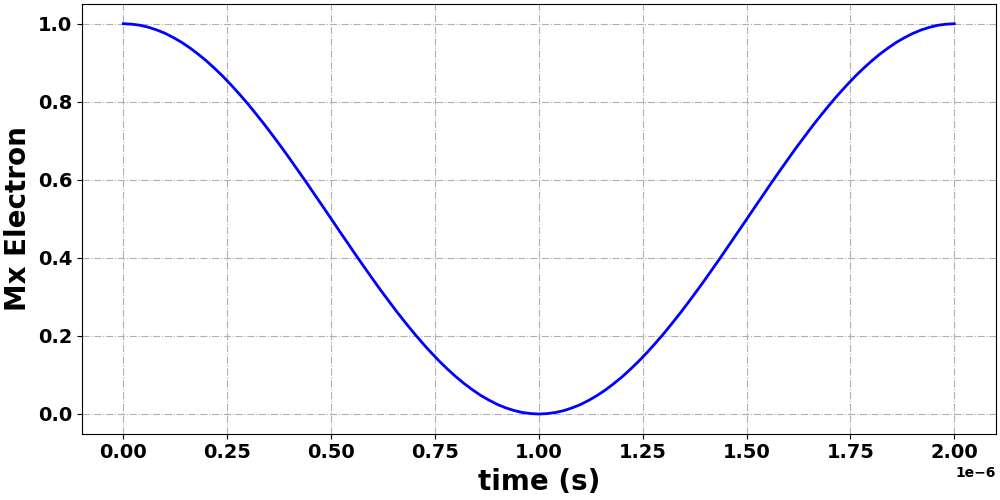

In [17]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting(t,signal_X1,"time (s)","Mx Electron","blue")